# Price forecast model comparison

Which model should produce the day-ahead price forecasts on the dashboard, and why?

**Setup.** Every model forecasts each quarter-hour of the next local day at 11:40 on
the day before, using only information published by then (see
`src/forecasting/information.py`). Forecasts are walk-forward: a model never sees
the day it forecasts. Scores cover the validation window, 1 June 2024 to 31 May
2026. The hold-out from 1 June 2026 is not touched here.

**Candidates.**

| Model | Idea | Reference |
|---|---|---|
| `lear` | Sparse linear model on arcsinh-scaled prices, conformal ranges | LEAR, Lago et al. 2021 |
| `lightgbm_quantile` | One gradient-boosted model per quantile, pinball loss | Widely used quantile GBM |
| `lightgbm_conformal` | Gradient-boosted median model, conformal ranges per hour | Split conformal prediction |
| `quantile_forest` | Random forest keeping leaf prices, any quantile | Meinshausen 2006 |
| `mstl` | Daily and weekly seasonal decomposition of recent prices | statsforecast MSTL |
| `qra` | Regularized quantile regression on the other models' medians | Nowotarski and Weron 2015; Uniejewski and Weron 2021 |
| `naive_previous_day`, `seasonal_naive_previous_week` | Baselines to beat | Phase 1 |

**Selection rules** (docs/decisions.md): lowest mean pinball loss on the validation
window; honest coverage of the 50%, 80% and 90% ranges; performance on the
15-minute months, negative-price days and spike days; a Diebold-Mariano test so a
win is not noise; run time that fits the 11:40 deadline; a near tie goes to the
simpler, better calibrated model. Phase 4 re-checks the top models on trading profit.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import REPO_ROOT, load_settings
from src.forecasting.base import quantile_column
from src.forecasting.evaluate import daily_pinball, diebold_mariano, pinball, score, segment_scores
from src.forecasting.walkforward import day_range

warnings.filterwarnings("ignore")
settings = load_settings()
QUANTILES = settings.forecasting.quantiles
FORECASTS = settings.data.processed_path / "forecasts" / "comparison"
ORDER = ["lightgbm_conformal", "lightgbm_quantile", "quantile_forest", "qra", "mstl", "lear",
         "naive_previous_day", "seasonal_naive_previous_week"]
COLORS = dict(zip(ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
                           "#898781", "#c3c2b7"], strict=True))
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "font.size": 9,
                     "axes.axisbelow": True, "legend.frameon": False})

runs = {}
for name in ORDER:
    path = FORECASTS / f"{name}.parquet"
    if path.exists():
        table = pd.read_parquet(path)
        runs[name] = table[[d >= settings.evaluation.validation_start for d in table["target_day"]]]
print({name: f"{t['target_day'].nunique()} days" for name, t in runs.items()})


{'lightgbm_conformal': '730 days', 'lightgbm_quantile': '730 days', 'quantile_forest': '730 days', 'qra': '730 days', 'mstl': '730 days', 'lear': '730 days', 'naive_previous_day': '730 days', 'seasonal_naive_previous_week': '730 days'}


## Overall scores on the validation window

Sorted by mean pinball loss, lower is better. Coverage should be close to the nominal level.

In [2]:
rows = {}
naive = score(runs["naive_previous_day"], QUANTILES)["mean pinball"]
for name, table in runs.items():
    s = score(table, QUANTILES)
    valid = table[table["actual"].notna()]
    crossings = int(table["crossings_repaired"].groupby(table["target_day"]).first().sum())
    rows[name] = {
        "mean pinball": round(s["mean pinball"], 2),
        "vs naive": f"{s['mean pinball'] / naive - 1:+.1%}",
        "MAE of median": round(s["MAE of median"], 2),
        "RMSE of median": round(s["RMSE of median"], 2),
        "coverage 50%": f"{s['coverage 50%']:.1%}",
        "coverage 80%": f"{s['coverage 80%']:.1%}",
        "coverage 90%": f"{s['coverage 90%']:.1%}",
        "median width 90%": round(float((valid["q95"] - valid["q05"]).median()), 1),
        "periods with crossed quantiles": crossings,
    }
overall = pd.DataFrame(rows).T.sort_values("mean pinball")
overall


,mean pinball,vs naive,MAE of median,RMSE of median,coverage 50%,coverage 80%,coverage 90%,median width 90%,periods with crossed quantiles
lightgbm_quantile,5.0,-47.9%,15.43,27.61,30.3%,56.8%,73.3%,40.7,47184
lightgbm_conformal,5.11,-46.8%,16.03,27.9,48.6%,76.3%,85.6%,58.7,0
quantile_forest,5.18,-46.1%,16.8,30.72,59.7%,87.6%,94.6%,82.0,0
qra,5.21,-45.8%,15.6,27.89,48.7%,78.1%,88.9%,72.5,3522
mstl,7.74,-19.4%,22.69,36.71,69.6%,89.8%,94.4%,128.2,0
lear,8.06,-16.1%,24.59,62.54,45.7%,75.7%,84.9%,82.5,0
naive_previous_day,9.61,+0.0%,29.05,46.11,48.0%,78.5%,86.4%,128.6,0
seasonal_naive_previous_week,11.49,+19.6%,35.34,56.82,47.7%,77.6%,85.4%,136.4,0


## Mean pinball loss by segment

The 15-minute months, negative-price days and spike days are where trading value concentrates.

In [3]:
segments = pd.DataFrame({
    name: segment_scores(table, settings)["mean pinball"].round(2) for name, table in runs.items()
}).T
segments = segments.drop(columns=["Validation window"]).loc[overall.index]
segments


,All target days,15-minute products,Days with a negative price,Days with a price above €200
lightgbm_quantile,5.00,4.70,5.43,7.78
lightgbm_conformal,5.11,4.96,5.17,8.20
quantile_forest,5.18,4.91,5.29,8.11
qra,5.21,4.91,5.49,8.74
mstl,7.74,7.81,7.86,10.01
lear,8.06,8.29,9.56,12.67
naive_previous_day,9.61,9.49,10.13,13.57
seasonal_naive_previous_week,11.49,11.81,11.24,14.03


## Stability over time

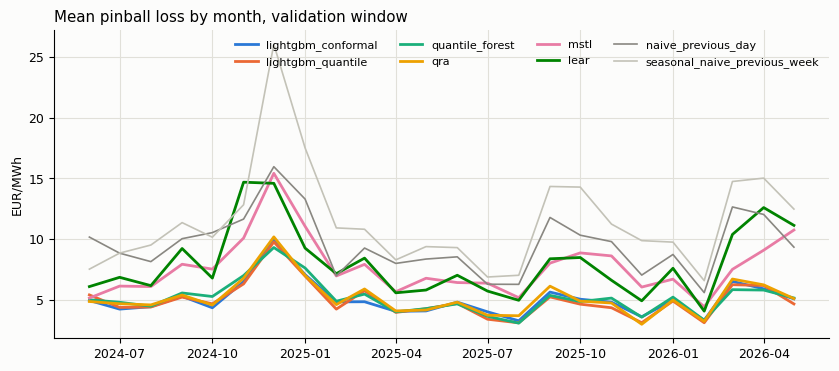

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, table in runs.items():
    daily = daily_pinball(table, QUANTILES)
    monthly = daily.groupby([pd.Timestamp(d).to_period("M") for d in daily.index]).mean()
    ax.plot(monthly.index.to_timestamp(), monthly.to_numpy(), label=name, color=COLORS[name],
            linewidth=2 if not name.startswith(("naive", "seasonal")) else 1.2)
ax.set_title("Mean pinball loss by month, validation window", loc="left")
ax.set_ylabel("EUR/MWh")
ax.legend(ncols=4, frameon=False, fontsize=8)
plt.show()


## Calibration

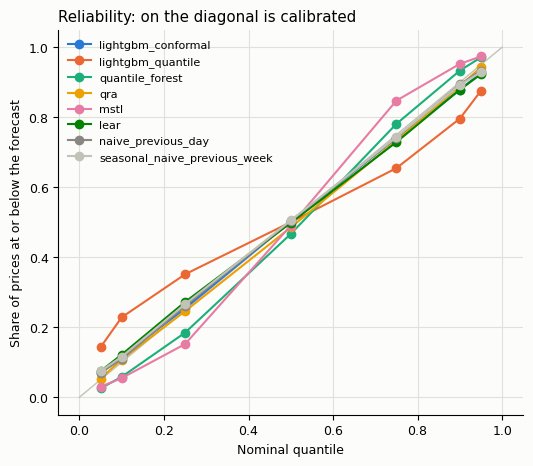

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1)
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    empirical = [float(np.mean(valid["actual"] <= valid[quantile_column(q)])) for q in QUANTILES]
    ax.plot(QUANTILES, empirical, marker="o", color=COLORS[name], label=name, linewidth=1.5)
ax.set_xlabel("Nominal quantile")
ax.set_ylabel("Share of prices at or below the forecast")
ax.set_title("Reliability: on the diagonal is calibrated", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.show()


Share of prices at or below each forecast quantile. A calibrated model matches the quantile level.

In [6]:
shares = {}
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    shares[name] = {
        f"q{round(q * 100):02d}": f"{np.mean(valid['actual'] <= valid[quantile_column(q)]):.1%}"
        for q in QUANTILES
    }
pd.DataFrame(shares).T.loc[overall.index]


,q05,q10,q25,q50,q75,q90,q95
lightgbm_quantile,14.3%,22.8%,35.1%,50.0%,65.5%,79.6%,87.6%
lightgbm_conformal,7.0%,11.5%,25.4%,50.3%,74.0%,87.8%,92.7%
quantile_forest,2.5%,5.8%,18.4%,46.7%,78.1%,93.3%,97.1%
qra,5.3%,10.7%,24.6%,48.5%,73.3%,88.9%,94.3%
mstl,3.0%,5.5%,15.2%,49.0%,84.8%,95.2%,97.4%
lear,7.4%,12.2%,27.2%,49.8%,72.9%,87.9%,92.3%
naive_previous_day,6.9%,10.9%,26.1%,50.4%,74.1%,89.4%,93.3%
seasonal_naive_previous_week,7.5%,11.6%,26.6%,50.5%,74.3%,89.2%,92.9%


## Error by hour of day

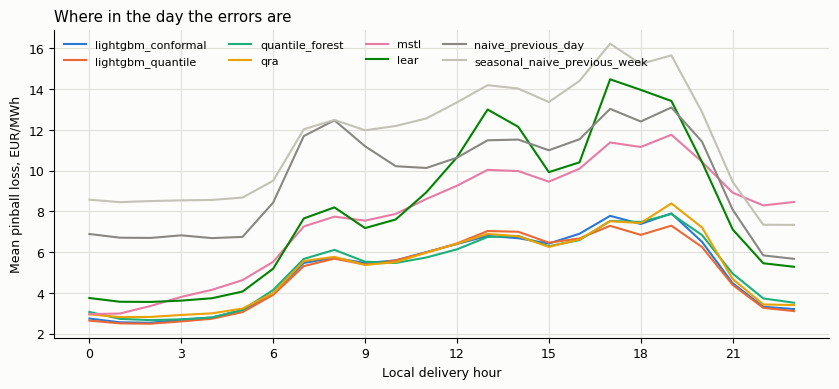

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, table in runs.items():
    valid = table[table["actual"].notna()]
    actual = valid["actual"].to_numpy()
    loss = np.mean([pinball(actual, valid[quantile_column(q)].to_numpy(), q) for q in QUANTILES], axis=0)
    hours = pd.DatetimeIndex(valid.index).tz_convert(settings.market.timezone).hour
    ax.plot(range(24), pd.Series(loss).groupby(hours).mean().to_numpy(), color=COLORS[name], label=name)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Local delivery hour")
ax.set_ylabel("Mean pinball loss, EUR/MWh")
ax.set_title("Where in the day the errors are", loc="left")
ax.legend(ncols=4, frameon=False, fontsize=8)
plt.show()


## Is a win significant?

Diebold-Mariano test on daily mean pinball loss, Newey-West variance over seven days. First against the lowest-loss model:

In [8]:
def dm_table(reference):
    """Diebold-Mariano test of every model against ``reference`` on daily pinball loss."""
    ref = daily_pinball(runs[reference], QUANTILES)
    calendar = day_range(min(ref.index), max(ref.index))
    rows = {}
    for name, table in runs.items():
        if name == reference:
            continue
        other = daily_pinball(table, QUANTILES).reindex(calendar).to_numpy()
        statistic, p_value = diebold_mariano(other, ref.reindex(calendar).to_numpy())
        rows[name] = {"DM statistic, positive means worse": round(statistic, 2),
                      "p-value": f"{p_value:.4f}"}
    return pd.DataFrame(rows).T


best = overall.index[0]
chosen = settings.forecasting.production_model
print(f"Lowest mean pinball loss: {best}. Production model: {chosen}.")
dm_table(best)


Lowest mean pinball loss: lightgbm_quantile. Production model: lightgbm_conformal.


,"DM statistic, positive means worse",p-value
lightgbm_conformal,1.59,0.1118
quantile_forest,2.93,0.0034
qra,3.26,0.0011
mstl,15.74,0.0000
lear,8.59,0.0000
naive_previous_day,19.97,0.0000
seasonal_naive_previous_week,14.0,0.0000


Then against the production model:

In [9]:
dm_table(chosen)


,"DM statistic, positive means worse",p-value
lightgbm_quantile,-1.59,0.1118
quantile_forest,0.89,0.3712
qra,1.8,0.0713
mstl,15.99,0.0000
lear,8.5,0.0000
naive_previous_day,19.41,0.0000
seasonal_naive_previous_week,14.03,0.0000


## Top three in detail

The production model and the two other models with the lowest mean pinball loss, compared on the criteria
behind the decision: accuracy with its uncertainty, calibration, coverage against sharpness, quantile
crossings and stability over time, then the segments and extreme days where the ranking changes.
Each title names what the chart shows; the subtitles are computed from the forecasts.


In [10]:
from matplotlib.ticker import PercentFormatter

INK, INK2, MUTED, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#c3c2b7", "#fcfcfb"
chosen = settings.forecasting.production_model
top3 = [chosen, *[name for name in overall.index if name != chosen][:2]]
top = {name: runs[name][runs[name]["actual"].notna()] for name in top3}
naive_valid = runs["naive_previous_day"][runs["naive_previous_day"]["actual"].notna()]
daily = {name: daily_pinball(top[name], QUANTILES) for name in top3}


def titled(fig, title, subtitle, top=0.8):
    fig.subplots_adjust(top=top)
    fig.text(0.01, 0.99, title, ha="left", va="top", fontsize=12, fontweight="bold", color=INK)
    fig.text(0.01, 0.925, subtitle, ha="left", va="top", fontsize=9, color=INK2, wrap=True)


print(f"Production model, ranked {list(overall.index).index(chosen) + 1} of {len(overall)} by mean pinball loss:", chosen)
print("Two best other models:", top3[1:])


Production model, ranked 2 of 8 by mean pinball loss: lightgbm_conformal
Two best other models: ['lightgbm_quantile', 'quantile_forest']


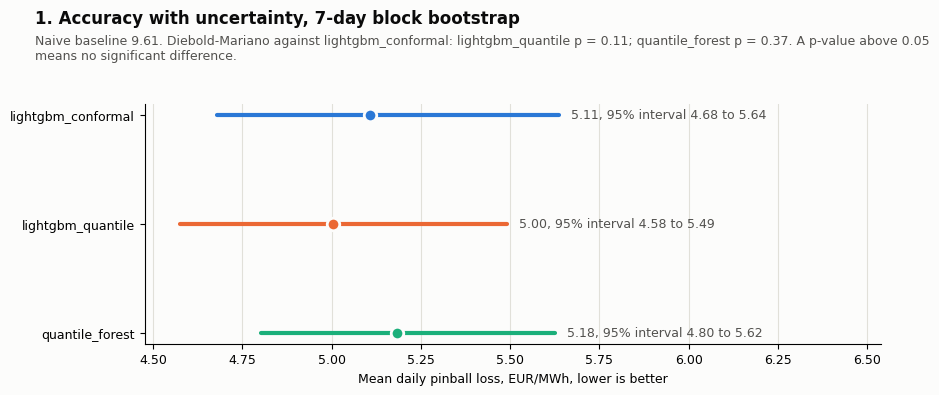

In [11]:
rng = np.random.default_rng(7)


reference = daily[chosen]
calendar = day_range(min(reference.index), max(reference.index))


def block_bootstrap_ci(values, block=7, draws=2000):
    values = values.reindex(calendar).to_numpy()  # calendar positions, missing days stay NaN
    n = len(values)
    means = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        means.append(np.nanmean(np.concatenate([values[s:s + block] for s in starts])[:n]))
    return np.percentile(means, [2.5, 97.5])


stats = {name: (daily[name].mean(), *block_bootstrap_ci(daily[name])) for name in top3}
p_values = {
    name: diebold_mariano(daily[name].reindex(calendar).to_numpy(), reference.reindex(calendar).to_numpy())[1]
    for name in top3 if name != chosen
}
fig, ax = plt.subplots(figsize=(9.5, 3.8))
rows = list(range(len(top3)))[::-1]
for y, name in zip(rows, top3):
    mean, lo, hi = stats[name]
    ax.plot([lo, hi], [y, y], color=COLORS[name], linewidth=3, solid_capstyle="round")
    ax.plot(mean, y, "o", color=COLORS[name], markersize=9, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.text(hi, y, f"   {mean:.2f}, 95% interval {lo:.2f} to {hi:.2f}", va="center", color=INK2, fontsize=9)
ax.set_yticks(rows, top3)
ax.set_xlim(min(s[1] for s in stats.values()) - 0.1, max(s[2] for s in stats.values()) + 0.9)
ax.set_xlabel("Mean daily pinball loss, EUR/MWh, lower is better")
ax.grid(axis="y", visible=False)
tests = "; ".join(f"{name} p = {p:.2f}" if p >= 0.01 else f"{name} p < 0.01" for name, p in p_values.items())
titled(fig, "1. Accuracy with uncertainty, 7-day block bootstrap",
       f"Naive baseline {daily_pinball(naive_valid, QUANTILES).mean():.2f}. Diebold-Mariano against {chosen}: "
       f"{tests}. A p-value above 0.05 means no significant difference.", top=0.74)
plt.show()


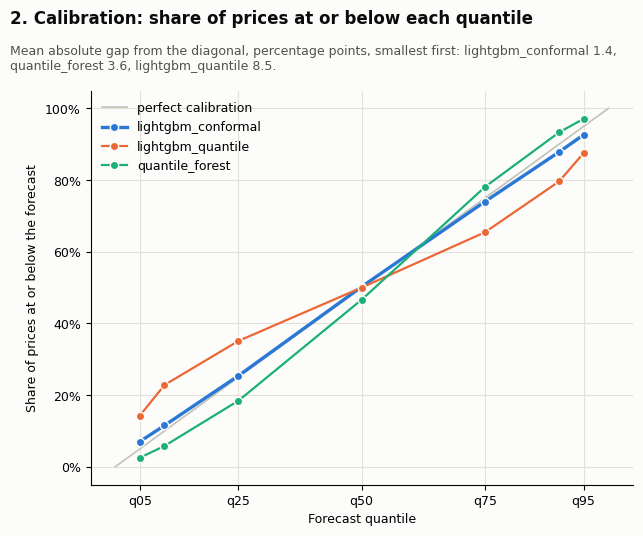

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.4))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2, label="perfect calibration")
gaps = {}
for name in top3:
    t = top[name]
    empirical = np.array([np.mean(t["actual"] <= t[quantile_column(q)]) for q in QUANTILES])
    gaps[name] = 100 * float(np.mean(np.abs(empirical - np.array(QUANTILES))))
    ax.plot(QUANTILES, empirical, marker="o", color=COLORS[name], label=name,
            linewidth=2.4 if name == chosen else 1.6, markeredgecolor=SURFACE)
ax.set_xticks([0.05, 0.25, 0.5, 0.75, 0.95], ["q05", "q25", "q50", "q75", "q95"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Forecast quantile")
ax.set_ylabel("Share of prices at or below the forecast")
ax.legend(loc="upper left")
ranked = ", ".join(f"{name} {gap:.1f}" for name, gap in sorted(gaps.items(), key=lambda kv: kv[1]))
titled(fig, "2. Calibration: share of prices at or below each quantile",
       f"Mean absolute gap from the diagonal, percentage points, smallest first: {ranked}.", top=0.84)
plt.show()


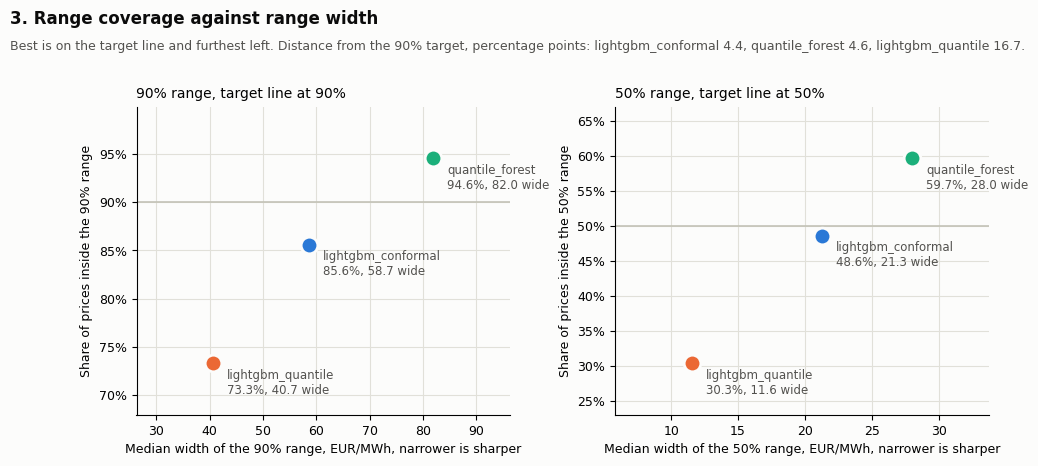

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
fig.subplots_adjust(wspace=0.28)
distance = {}
for ax, (low, high, target) in zip(axes, [(0.05, 0.95, 0.90), (0.25, 0.75, 0.50)]):
    ax.axhline(target, color=AXIS, linewidth=1.2)
    for name in top3:
        t = top[name]
        width = float((t[quantile_column(high)] - t[quantile_column(low)]).median())
        coverage = float(np.mean((t["actual"] >= t[quantile_column(low)]) & (t["actual"] <= t[quantile_column(high)])))
        if target == 0.90:
            distance[name] = abs(coverage - target) * 100
        ax.plot(width, coverage, "o", color=COLORS[name], markersize=12, markeredgecolor=SURFACE, markeredgewidth=2)
        ax.annotate(f"{name}\n{coverage:.1%}, {width:.1f} wide", (width, coverage), xytext=(10, -4),
                    textcoords="offset points", color=INK2, fontsize=8.5, va="top")
    ax.set_xlabel(f"Median width of the {target:.0%} range, EUR/MWh, narrower is sharper")
    ax.set_ylabel(f"Share of prices inside the {target:.0%} range")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_title(f"{target:.0%} range, target line at {target:.0%}", loc="left", fontsize=10)
    ax.margins(x=0.35, y=0.25)
ranked = ", ".join(f"{name} {d:.1f}" for name, d in sorted(distance.items(), key=lambda kv: kv[1]))
titled(fig, "3. Range coverage against range width",
       f"Best is on the target line and furthest left. Distance from the 90% target, percentage points: {ranked}.",
       top=0.78)
plt.show()


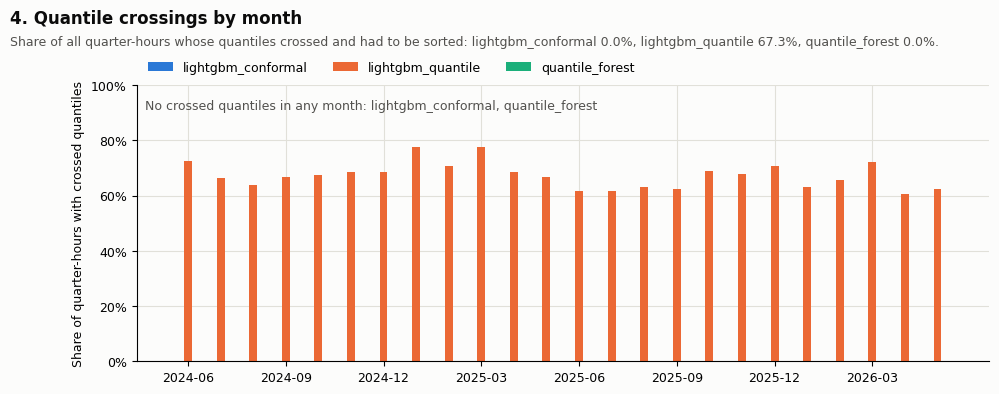

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
shares = {}
width = 0.27
for i, name in enumerate(top3):
    by_day = runs[name].groupby("target_day")
    crossed, periods = by_day["crossings_repaired"].first(), by_day.size()
    shares[name] = float(crossed.sum() / periods.sum())
    months = [pd.Timestamp(d).to_period("M") for d in crossed.index]
    monthly = crossed.groupby(months).sum() / periods.groupby(months).sum()
    x = np.arange(len(monthly))
    ax.bar(x + (i - 1) * width, monthly.to_numpy(), width=width * 0.9, color=COLORS[name], label=name)
ax.set_xticks(x[::3], [str(m) for m in monthly.index][::3])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 1)
ax.set_ylabel("Share of quarter-hours with crossed quantiles")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3)
never = [name for name, share in shares.items() if share == 0]
if never:
    ax.text(0.01, 0.95, f"No crossed quantiles in any month: {', '.join(never)}", transform=ax.transAxes,
            ha="left", va="top", fontsize=9, color=INK2)
summary = ", ".join(f"{name} {share:.1%}" for name, share in shares.items())
titled(fig, "4. Quantile crossings by month",
       f"Share of all quarter-hours whose quantiles crossed and had to be sorted: {summary}.")
plt.show()


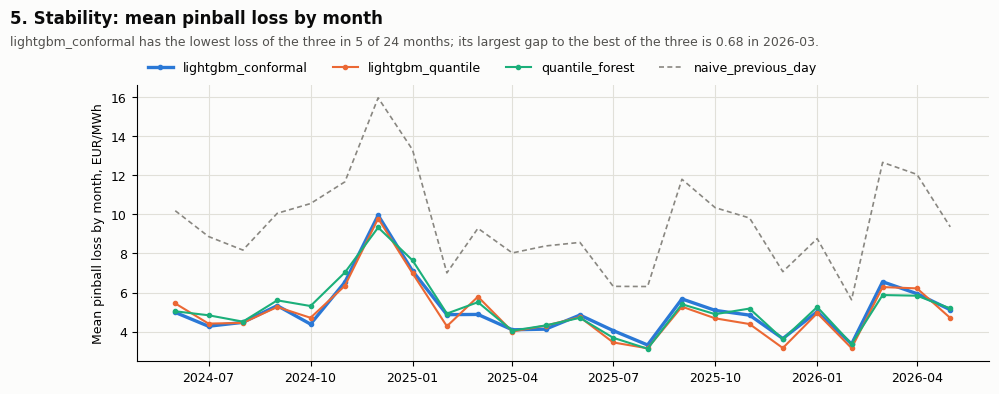

In [15]:
monthly = pd.DataFrame({
    name: daily[name].groupby([pd.Timestamp(d).to_period("M") for d in daily[name].index]).mean()
    for name in top3
})
naive_daily = daily_pinball(naive_valid, QUANTILES)
naive_monthly = naive_daily.groupby([pd.Timestamp(d).to_period("M") for d in naive_daily.index]).mean()
fig, ax = plt.subplots(figsize=(11, 4))
for name in top3:
    ax.plot(monthly.index.to_timestamp(), monthly[name].to_numpy(), color=COLORS[name], marker="o", markersize=3,
            linewidth=2.4 if name == chosen else 1.5, label=name)
ax.plot(naive_monthly.index.to_timestamp(), naive_monthly.to_numpy(), color=MUTED, linewidth=1.2,
        linestyle=(0, (3, 2)), label="naive_previous_day")
ax.set_ylabel("Mean pinball loss by month, EUR/MWh")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=4)
gap = monthly[chosen] - monthly.min(axis=1)
titled(fig, "5. Stability: mean pinball loss by month",
       f"{chosen} has the lowest loss of the three in {int((gap <= 1e-12).sum())} of {len(monthly)} months; "
       f"its largest gap to the best of the three is {gap.max():.2f} in {gap.idxmax()}.")
plt.show()


The last two charts show where the ranking changes.

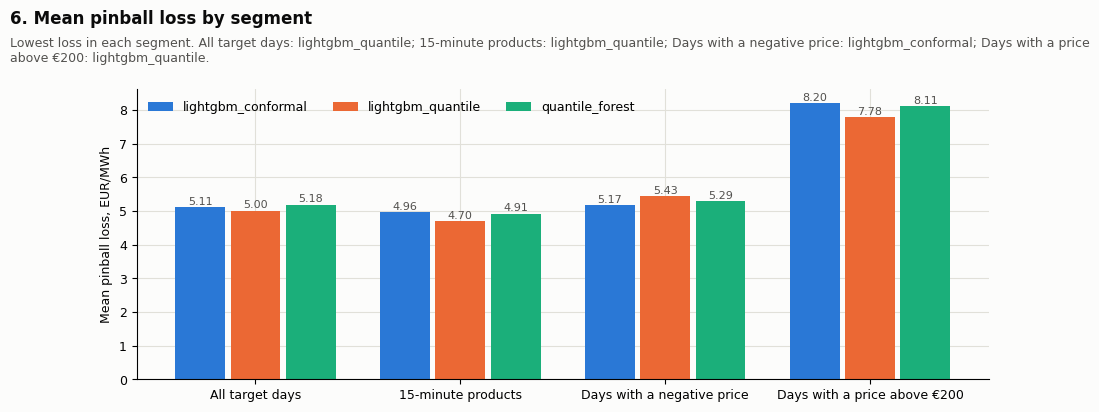

In [16]:
segment_names = ["All target days", "15-minute products", "Days with a negative price",
                 f"Days with a price above €{settings.evaluation.spike_threshold_eur_mwh:.0f}"]
segment_scores_top = pd.DataFrame(
    {name: segment_scores(top[name], settings)["mean pinball"].reindex(segment_names) for name in top3}
)
fig, ax = plt.subplots(figsize=(11, 4.2))
width = 0.27
for i, name in enumerate(top3):
    x = np.arange(len(segment_names))
    bars = ax.bar(x + (i - 1) * width, segment_scores_top[name].to_numpy(), width=width * 0.9,
                  color=COLORS[name], label=name)
    for bar, value in zip(bars, segment_scores_top[name].to_numpy()):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.08, f"{value:.2f}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(np.arange(len(segment_names)), segment_names)
ax.set_ylabel("Mean pinball loss, EUR/MWh")
ax.legend(loc="upper left", ncols=3)
lowest = "; ".join(f"{segment}: {segment_scores_top.loc[segment].idxmin()}" for segment in segment_names)
titled(fig, "6. Mean pinball loss by segment", f"Lowest loss in each segment. {lowest}.")
plt.show()


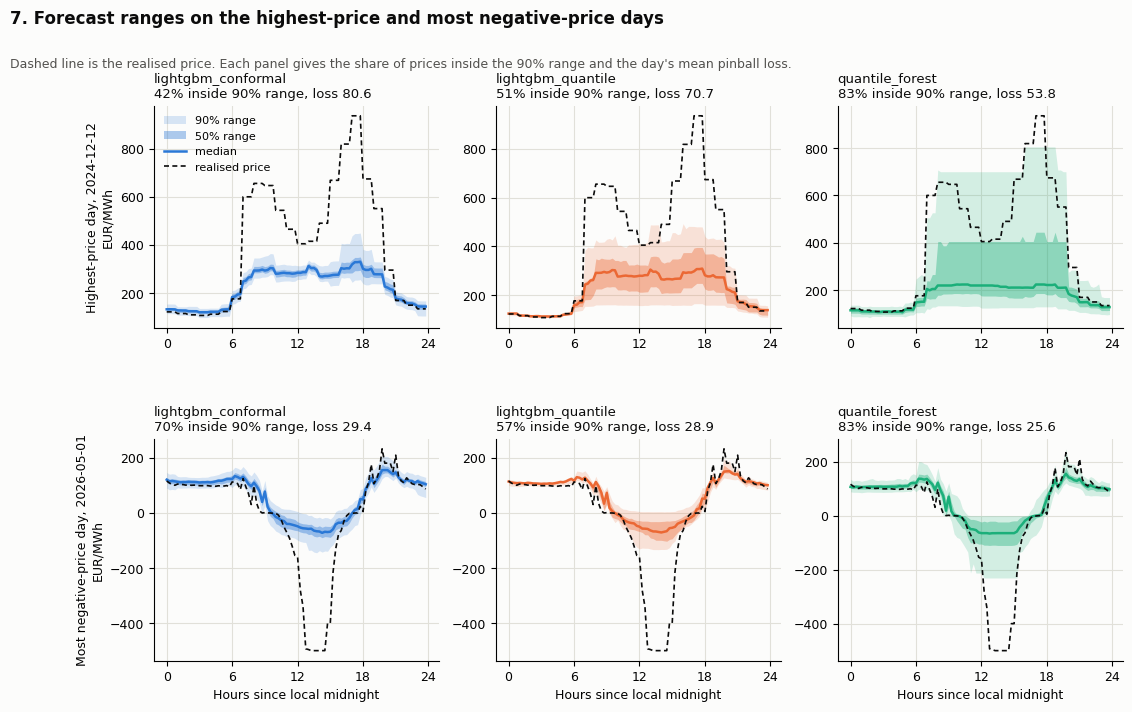

In [17]:
reference_days = top[chosen].groupby("target_day")["actual"]
examples = [("Highest-price day", reference_days.max().idxmax()), ("Most negative-price day", reference_days.min().idxmin())]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.4))
fig.subplots_adjust(hspace=0.5, wspace=0.2)
for row, (kind, day) in enumerate(examples):
    for col, name in enumerate(top3):
        ax = axes[row, col]
        t = top[name][top[name]["target_day"] == day]
        midnight = pd.Timestamp(day).tz_localize(settings.market.timezone)
        hour = (pd.DatetimeIndex(t.index) - midnight) / pd.Timedelta(hours=1)
        color = COLORS[name]
        ax.fill_between(hour, t["q05"], t["q95"], color=color, alpha=0.18, linewidth=0, label="90% range")
        ax.fill_between(hour, t["q25"], t["q75"], color=color, alpha=0.38, linewidth=0, label="50% range")
        ax.plot(hour, t["q50"], color=color, linewidth=1.8, label="median")
        ax.plot(hour, t["actual"], color=INK, linewidth=1.2, linestyle=(0, (3, 2)), label="realised price")
        inside = float(np.mean((t["actual"] >= t["q05"]) & (t["actual"] <= t["q95"])))
        loss = float(np.mean([pinball(t["actual"].to_numpy(), t[quantile_column(q)].to_numpy(), q) for q in QUANTILES]))
        ax.set_title(f"{name}\n{inside:.0%} inside 90% range, loss {loss:.1f}", loc="left", fontsize=9.5, color=INK)
        ax.set_xticks([0, 6, 12, 18, 24])
        if col == 0:
            ax.set_ylabel(f"{kind}, {day}\nEUR/MWh")
        if row == 1:
            ax.set_xlabel("Hours since local midnight")
axes[0, 0].legend(loc="upper left", fontsize=8)
titled(fig, "7. Forecast ranges on the highest-price and most negative-price days",
       "Dashed line is the realised price. Each panel gives the share of prices inside the 90% range and the day's mean pinball loss.",
       top=0.86)
plt.show()


## Run time

In [18]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{REPO_ROOT / 'mlflow.db'}")
found = mlflow.search_runs(experiment_names=["price-forecast-comparison"], order_by=["start_time DESC"])
columns = {"tags.model": "model", "metrics.run_seconds": "run seconds",
           "params.refit_every_days": "refit every days"}
if found.empty:
    runtime = pd.DataFrame(columns=list(columns.values()))
else:
    runtime = found.drop_duplicates("tags.model")[list(columns)].rename(columns=columns).set_index("model")
runtime


,run seconds,refit every days
model,,
qra,362.348214,7
lightgbm_conformal,706.080230,28
mstl,2681.857273,1
lear,98.559932,28
quantile_forest,334.436809,28
lightgbm_quantile,1077.627336,28
seasonal_naive_previous_week,9.690851,1
naive_previous_day,9.348401,1


## Decision: LightGBM conformal goes to production

| model | mean pinball | vs naive | 90% range coverage | median 90% width, EUR/MWh | crossed periods |
|---|---|---|---|---|---|
| lightgbm_quantile | 5.00 | -47.9% | 73.3% | 40.7 | 47,184 |
| **lightgbm_conformal** | **5.11** | **-46.8%** | **85.6%** | **58.7** | **0** |
| quantile_forest | 5.18 | -46.1% | 94.6% | 82.0 | 0 |
| qra | 5.21 | -45.8% | 88.9% | 72.5 | 3,522 |
| mstl | 7.74 | -19.4% | 94.4% | 128.2 | 0 |
| lear | 8.06 | -16.1% | 84.9% | 82.5 | 0 |
| naive_previous_day | 9.61 | +0.0% | 86.4% | 128.6 | 0 |
| seasonal_naive_previous_week | 11.49 | +19.6% | 85.4% | 136.4 | 0 |

All figures are from the tables and charts above. The top-three charts show the accuracy tie, the
calibration, the sharpness and the absence of crossings behind the choice. The monthly, segment and
extreme-day charts show where the chosen model is not the best of the three.

**Why LightGBM conformal.**

1. **It ties for the best accuracy.** Tested against it, LightGBM quantile gives p = 0.11 and the
   quantile forest p = 0.37: neither difference is significant. It is 46.8% better than naive.
2. **Its ranges are close to honest.** Prices fall below its q05 to q95 forecasts 7.0%, 11.5%, 25.4%,
   50.3%, 74.0%, 87.8% and 92.7% of the time, against targets of 5% to 95%.
3. **Its ranges are sharp.** The median 90% range is 58.7 EUR/MWh wide, against 82.0 for the quantile
   forest, which covers more than it should, and 72.5 for QRA.
4. **It never crosses quantiles and is a single model**, simple to run before the 11:40 deadline.

**Why not the others.**

- **LightGBM quantile** has the lowest loss, but its ranges are overconfident: its 90% range covers only
  73.3% of prices and its quantiles crossed in two thirds of all periods. On the dashboard that would
  understate spike and negative-price risk, the most expensive error for a battery.
- **QRA** is well calibrated, but it is not more accurate than LightGBM conformal (p = 0.07), it is
  worse on spike days, 8.74 against 8.20, and it needs all five member models running every day.
- **The quantile forest** is the conservative alternative: accurate, never crossing, but wider than needed.

**Weaknesses to watch.** The tails are slightly narrow, 85.6% coverage for a 90% range. On spike days
LightGBM quantile is better, 7.78 against 8.20. Month by month it has the lowest loss of the three in
only 5 of 24 months, and on the 15-minute months it is the weakest of the three, 4.96 against 4.91 for
the quantile forest and 4.70 for LightGBM quantile. On the two most extreme days its ranges are too
narrow: on 2024-12-12 only 42% of prices fell inside its 90% range, a loss of 80.6 against 53.8 for the
quantile forest, and no model foresaw the -500 EUR/MWh prices of 2026-05-01. Hyperparameters are
defaults, not tuned. Phase 4
re-checks the top three models on trading profit, and Phase 6 monitors coverage drift.
